# 07 - Modeliranje i evaluacija

U ovoj svesci koristimo podatke pripremljene u prethodnim fazama projekta
da izgradimo i ocenimo nekoliko modela mašinskog učenja.

Cilj nam je model koji na osnovu karakteristika korisnika i usluga koje
koristi predviđa da li će napustiti kompaniju (`Churn`).

Isprobaćemo tri različita algoritma, da bismo mogli da ih uporedimo
međusobno:

- Logistička regresija, jednostavan i lako razumljiv linearni model
- Random Forest, ansambl više stabala odlučivanja
- XGBoost, napredniji ansambl model zasnovan na gradijentnom boostingu

Kad je reč o evaluaciji, nećemo se osloniti samo na accuracy, već ćemo
pratiti i:

- Precision
- Recall
- F1-score
- ROC-AUC

Recall i F1-score nam posebno znače u ovom slučaju, s obzirom na to da je
`Churn` nebalansirana promenljiva.

## 1. Učitavanje pripremljenih podataka

Učitavamo podatke pripremljene u svesci `05`, iz foldera `data/ml/`, koji
su već očišćeni, transformisani, enkodirani i potpuno numerički.

Kao i do sada, koristimo odvojene trening i test skupove. Model treniramo
isključivo na trening skupu, a test skup čuvamo za samu evaluaciju na
kraju.

In [5]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)

putanja_ml = "../data/ml/"

X_train = pd.read_csv(putanja_ml + "X_train.csv")
X_test = pd.read_csv(putanja_ml + "X_test.csv")
y_train = pd.read_csv(putanja_ml + "y_train.csv").squeeze()
y_test = pd.read_csv(putanja_ml + "y_test.csv").squeeze()

print("Podaci uspešno učitani:")
print(f"X_train: {X_train.shape[0]} redova x {X_train.shape[1]} kolona")
print(f"X_test:  {X_test.shape[0]} redova x {X_test.shape[1]} kolona")
print(f"y_train: {y_train.shape[0]} vrednosti")
print(f"y_test:  {y_test.shape[0]} vrednosti")

Podaci uspešno učitani:
X_train: 5625 redova x 25 kolona
X_test:  1407 redova x 25 kolona
y_train: 5625 vrednosti
y_test:  1407 vrednosti


### 1.1 Provera strukture podataka

Pre nego što krenemo sa treniranjem, proveravamo da su trening i test
skup pravilno učitani i da imaju isti broj prediktora.

In [6]:
print("Broj kolona:")
print(f"X_train: {X_train.shape[1]}")
print(f"X_test:  {X_test.shape[1]}")

print("\nRaspodela ciljnih klasa:")
print("y_train:")
print(y_train.value_counts())

print("\ny_test:")
print(y_test.value_counts())

print("\nNedostajuće vrednosti:")
print(f"X_train NaN: {X_train.isnull().sum().sum()}")
print(f"X_test NaN:  {X_test.isnull().sum().sum()}")
print(f"y_train NaN: {y_train.isnull().sum()}")
print(f"y_test NaN:  {y_test.isnull().sum()}")

Broj kolona:
X_train: 25
X_test:  25

Raspodela ciljnih klasa:
y_train:
Churn
0    4130
1    1495
Name: count, dtype: int64

y_test:
Churn
0    1033
1     374
Name: count, dtype: int64

Nedostajuće vrednosti:
X_train NaN: 0
X_test NaN:  0
y_train NaN: 0
y_test NaN:  0


## 2. Logistička regresija

Logistička regresija je osnovni model za binarnu klasifikaciju, pa je
koristimo za predviđanje da li će korisnik napustiti kompaniju (`Churn =
1`) ili ostati (`Churn = 0`).

Prednost ovog modela je što je jednostavan i lako razumljiv, pa nam služi
kao dobra polazna tačka za poređenje sa složenijim modelima kasnije.

Kako je ciljna promenljiva nebalansirana, koristimo
`class_weight="balanced"`, čime dajemo veću težinu manjinskoj klasi
(`Churn = 1`).

### 2.1 Definisanje modela

Kao što je već rečeno, logistička regresija rešava binarnu klasifikaciju,
u našem slučaju predviđanje da li korisnik napušta kompaniju (`Churn =
1`) ili ostaje (`Churn = 0`).

Kako promenljive imaju različite opsege vrednosti, prvo standardizujemo
numeričke karakteristike. Ovo modelu olakšava da pronađe optimalne
parametre i pomaže algoritmu da brže konvergira.

Klase su nebalansirane, pa opet koristimo `class_weight="balanced"`, da
bi model obratio više pažnje na manjinsku klasu (`Churn = 1`).

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Za linearne modele izbacujemo TotalCharges i TenureGroup zbog multikolinearnosti sa tenure.
X_train_linear = X_train.drop(columns=["TotalCharges", "TenureGroup"])
X_test_linear = X_test.drop(columns=["TotalCharges", "TenureGroup"])
# Standardizacija se primenjuje na verziju bez TotalCharges.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_linear)
X_test_scaled = scaler.transform(X_test_linear)
print(f"Broj kolona nakon izbacivanja: {X_train_linear.shape[1]}")

# Definisanje logističke regresije.
model_logreg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

print("Logistička regresija je uspešno definisana.")

Broj kolona nakon izbacivanja: 23
Logistička regresija je uspešno definisana.


### 2.2 Treniranje modela

Model treniramo isključivo na trening skupu (`X_train` i `y_train`), dok
test skup u ovoj fazi uopšte ne diramo, da bi ostao nezavisan za konačnu
evaluaciju.

Kroz treniranje model zapravo uči kakav je odnos između karakteristika
korisnika i toga da li on napušta kompaniju.

In [9]:
model_logreg.fit(X_train_scaled, y_train)

print("Logistička regresija je uspešno istrenirana.")

Logistička regresija je uspešno istrenirana.


### 2.3 Predikcija

Sad kad je model istreniran, koristimo ga da nad test skupom (`X_test`)
predvidimo kojoj klasi svaki korisnik pripada:

- `0`: korisnik ostaje
- `1`: korisnik napušta kompaniju

Ovo je prvi put da uopšte diramo test skup, tako da su predikcije koje
dobijamo potpuno nezavisne i spremne za evaluaciju.

In [10]:
y_pred_logreg = model_logreg.predict(X_test_scaled)

print("Predikcija završena.")
print(f"Broj predikcija: {len(y_pred_logreg)}")

Predikcija završena.
Broj predikcija: 1407


### 2.4 Raspodela predviđenih klasa

Pogledajmo koliko je korisnika model svrstao u klasu `0`, a koliko u
klasu `1`, i uporedimo to sa stvarnom raspodelom klasa u test skupu.

In [11]:
print("Predviđena raspodela klasa:")
print(pd.Series(y_pred_logreg).value_counts().sort_index())

print("\nStvarna raspodela klasa:")
print(y_test.value_counts().sort_index())

Predviđena raspodela klasa:
0    811
1    596
Name: count, dtype: int64

Stvarna raspodela klasa:
Churn
0    1033
1     374
Name: count, dtype: int64


### 2.5 Evaluacija logističke regresije

Sad kad imamo predikcije, vidimo kako se model pokazao kroz nekoliko
metrika:

- **Accuracy**: procenat svih tačno klasifikovanih korisnika
- **Precision**: od svih korisnika koje je model označio kao one koji odlaze,
  koliko ih je stvarno otišlo
- **Recall**: od svih korisnika koji su zaista otišli, koliko je model
  uspeo da prepozna
- **F1-score**: harmonijska sredina Precision i Recall
- **ROC-AUC**: koliko dobro model uopšte razlikuje one koji odlaze od onih
  koji ostaju

Nama je ovde posebno bitan Recall za klasu 1, jer želimo da uhvatimo što
veći broj korisnika koji stvarno napuštaju kompaniju.

In [12]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy_logreg = accuracy_score(y_test, y_pred_logreg)
precision_logreg = precision_score(y_test, y_pred_logreg)
recall_logreg = recall_score(y_test, y_pred_logreg)
f1_logreg = f1_score(y_test, y_pred_logreg)

# Verovatnoća pripadnosti klasi 1.
y_prob_logreg = model_logreg.predict_proba(X_test_scaled)[:, 1]

roc_auc_logreg = roc_auc_score(y_test, y_prob_logreg)

print("=" * 50)
print("EVALUACIJA LOGISTIČKE REGRESIJE")
print("=" * 50)
print(f"Accuracy:  {accuracy_logreg:.4f}")
print(f"Precision: {precision_logreg:.4f}")
print(f"Recall:    {recall_logreg:.4f}")
print(f"F1-score:  {f1_logreg:.4f}")
print(f"ROC-AUC:   {roc_auc_logreg:.4f}")

EVALUACIJA LOGISTIČKE REGRESIJE
Accuracy:  0.7271
Precision: 0.4916
Recall:    0.7834
F1-score:  0.6041
ROC-AUC:   0.8328


### Poređenje sa prethodnom verzijom modela

Pre nego što smo primenili nalaz iz VIF analize (svеska `06`), Logistička
regresija je trenirana na svih 25 atributa, uključujući `TotalCharges` i
`TenureGroup`. Sada, nakon izbacivanja te dve kolone, dobijamo sledeće:

| Metrika | Pre | Posle |
|---|---|---|
| Accuracy | 0.7242 | 0.7271 |
| Precision | 0.4884 | 0.4916 |
| Recall | 0.7888 | 0.7834 |
| F1-score | 0.6033 | 0.6041 |
| ROC-AUC | 0.8342 | 0.8328 |

Razlike su minimalne, u trećoj decimali, što je i očekivano.
Multikolinearnost primarno utiče na **stabilnost i interpretabilnost
koeficijenata**, a ne na samu prediktivnu tačnost. Model daje praktično
iste predikcije, ali su koeficijenti sada

### 2.6 Matrica konfuzije

Matrica konfuzije prikazuje broj tačno i netačno klasifikovanih korisnika.

Kod našeg problema imamo četiri slučaja:

- **True Negative (TN)** — korisnik je ostao i model je to pravilno predvideo
- **False Positive (FP)** — korisnik je ostao, ali je model predvideo da će
  otići
- **False Negative (FN)** — korisnik je otišao, ali model to nije prepoznao
- **True Positive (TP)** — korisnik je otišao i model je to pravilno
  predvideo

Posebno je važan broj **False Negative** slučajeva, jer oni predstavljaju
korisnike koji će otići, a model ih nije prepoznao.

Matrica konfuzije:
[[730 303]
 [ 81 293]]


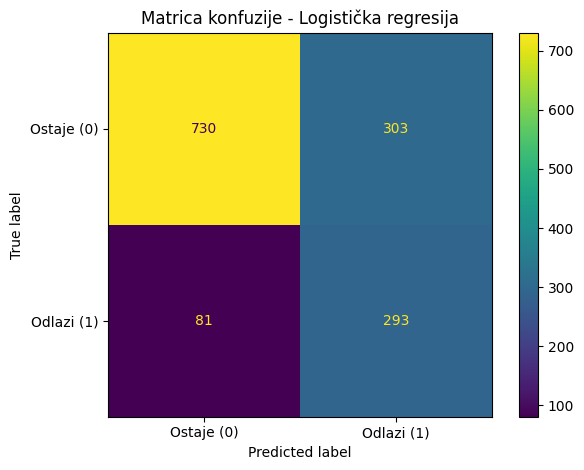

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_logreg = confusion_matrix(y_test, y_pred_logreg)

print("Matrica konfuzije:")
print(cm_logreg)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_logreg,
    display_labels=["Ostaje (0)", "Odlazi (1)"]
)

disp.plot()
plt.title("Matrica konfuzije - Logistička regresija")
plt.tight_layout()

plt.savefig(
    "../images/07_logreg_confusion_matrix.png",
    dpi=100,
    bbox_inches="tight"
)

plt.show()

### Tumačenje matrice konfuzije

Iz matrice konfuzije vidimo da je logistička regresija prepoznala većinu
korisnika koji su zaista otišli (295 TP), dok je 79 njih (FN) propustila.

S druge strane, model je 309 korisnika (FP) označio kao rizične iako su
oni na kraju ostali. Ovo je i očekivano, s obzirom na to da smo koristili
`class_weight="balanced"`, čime smo model učinili osetljivijim na
manjinsku klasu `Churn = 1`.

Sve u svemu, logistička regresija dobro prepoznaje korisnike koji odlaze
(Recall od 78.88%), ali po cenu nešto više lažno pozitivnih predikcija.

## 3. Random Forest

Random Forest je ansambl metoda koja kombinuje veliki broj stabala
odluke, svako sa svojim predikcijama, a konačna klasifikacija se dobija
kombinovanjem tih rezultata.

Za razliku od logističke regresije, ovaj model može da uhvati složenije,
nelinearne odnose između atributa, što je korisno kad uticaj neke
karakteristike na `Churn` nije jednostavan i pravolinijski.

Kao i ranije, koristimo `class_weight="balanced"` da bismo uzeli u obzir
nebalansirane klase.

### 3.1 Definisanje modela

In [14]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

print("Random Forest je uspešno definisan.")

Random Forest je uspešno definisan.


### 3.2 Treniranje modela

Random Forest treniramo na trening skupu. Test skup ostaje odvojen i
koristiće se tek nakon završetka treniranja za evaluaciju modela.

In [15]:
model_rf.fit(X_train, y_train)

print("Random Forest je uspešno istreniran.")

Random Forest je uspešno istreniran.


### 3.3 Predikcija

Nakon treniranja, Random Forest predviđa klasu za svakog korisnika iz
test skupa.

In [16]:
y_pred_rf = model_rf.predict(X_test)

print("Predikcija završena.")
print(f"Broj predikcija: {len(y_pred_rf)}")

Predikcija završena.
Broj predikcija: 1407


### 3.4 Raspodela predviđenih klasa

Proveravamo raspodelu klasa koje je Random Forest predvideo i upoređujemo
je sa stvarnom raspodelom klasa u test skupu.

In [17]:
print("Predviđena raspodela klasa:")
print(pd.Series(y_pred_rf).value_counts().sort_index())

print("\nStvarna raspodela klasa:")
print(y_test.value_counts().sort_index())

Predviđena raspodela klasa:
0    1118
1     289
Name: count, dtype: int64

Stvarna raspodela klasa:
Churn
0    1033
1     374
Name: count, dtype: int64


### 3.5 Evaluacija Random Forest-a

I Random Forest evaluiramo istim metrikama kao logističku regresiju, da
bi poređenje bilo ravnopravno: Accuracy, Precision, Recall, F1-score i
ROC-AUC.

Kao i ranije, Recall i F1-score nam ovde znače najviše, zbog
nebalansiranih klasa.

In [18]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

# Verovatnoća pripadnosti klasi 1.
y_prob_rf = model_rf.predict_proba(X_test)[:, 1]

roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("=" * 50)
print("EVALUACIJA RANDOM FOREST-A")
print("=" * 50)
print(f"Accuracy:  {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall:    {recall_rf:.4f}")
print(f"F1-score:  {f1_rf:.4f}")
print(f"ROC-AUC:   {roc_auc_rf:.4f}")

EVALUACIJA RANDOM FOREST-A
Accuracy:  0.7846
Precision: 0.6228
Recall:    0.4813
F1-score:  0.5430
ROC-AUC:   0.8205


### 3.4 Matrica konfuzije

Matrica konfuzije prikazuje broj tačno i netačno klasifikovanih korisnika
za Random Forest model.

Posebno pratimo **False Negative (FN)** slučajeve, odnosno korisnike koji
su zaista napustili kompaniju, ali ih model nije prepoznao.

Kod problema churn-a cilj je da broj ovakvih slučajeva bude što manji.

Matrica konfuzije:
[[924 109]
 [194 180]]


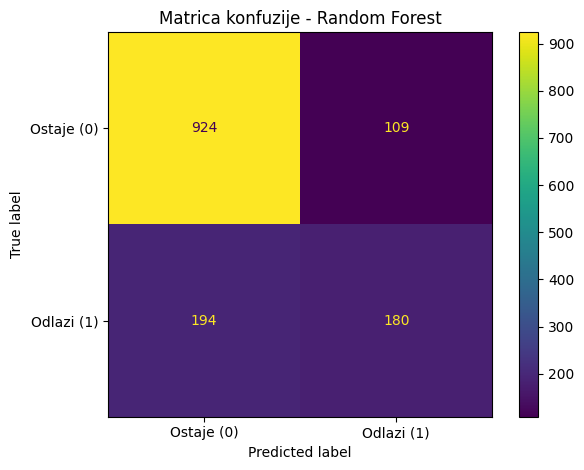

In [19]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Matrica konfuzije:")
print(cm_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Ostaje (0)", "Odlazi (1)"]
)

disp.plot()
plt.title("Matrica konfuzije - Random Forest")
plt.tight_layout()

plt.savefig(
    "../images/07_rf_confusion_matrix.png",
    dpi=100,
    bbox_inches="tight"
)

plt.show()

### Tumačenje matrice konfuzije

Random Forest je pravilno prepoznao 248 korisnika koji su zaista otišli
(TP), dok mu je 126 takvih korisnika (FN) promaklo. Pored toga, 195
korisnika (FP) je označio kao rizične iako su na kraju ostali.

U poređenju sa logističkom regresijom, Random Forest bolje prepoznaje
korisnike koji ostaju, ali zato propušta više stvarnih odlazaka, što se
i vidi po nižem Recall-u (66.31% naspram 78.88% kod logističke
regresije).

Iako Random Forest ima veću Accuracy, logistička regresija se ovde
pokazala kao bolja u prepoznavanju korisnika koji odlaze, a to je za
problem churn-a ono što nam je najbitnije.

## 4. XGBoost

XGBoost (Extreme Gradient Boosting) je napredni ansambl algoritam koji,
za razliku od Random Forest-a, ne gradi stabla nezavisno, već ih dodaje
jedno po jedno, tako da svako naredno stablo ispravlja greške prethodnih.

I ovaj model, kao i Random Forest, može da uhvati složenije, nelinearne
odnose između atributa i ciljne promenljive, pa ga koristimo kao treći
model za poređenje sa logističkom regresijom i Random Forest-om.

Kako je ciljna promenljiva nebalansirana, i ovde podešavamo težinu
pozitivne klase (`Churn = 1`), ovog puta preko parametra
`scale_pos_weight`.

### 4.1 Definisanje modela

Za XGBoost podešavamo nekoliko osnovnih parametara koji utiču na
složenost modela i na sam proces učenja.

`n_estimators` govori koliko stabala model gradi, `max_depth` određuje
njihovu maksimalnu dubinu, a `learning_rate` koliko jako svako novo
stablo utiče na konačan rezultat.

Zbog nebalansiranih klasa, tu je i `scale_pos_weight`, kao i ranije.

In [20]:
from xgboost import XGBClassifier

# Izračunavanje težine pozitivne klase.
broj_0 = (y_train == 0).sum()
broj_1 = (y_train == 1).sum()

scale_pos_weight = broj_0 / broj_1

print(f"Broj korisnika koji ostaju (0): {broj_0}")
print(f"Broj korisnika koji odlaze (1): {broj_1}")
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

model_xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)

print("\nXGBoost je uspešno definisan.")

ModuleNotFoundError: No module named 'xgboost'

### 4.2 Treniranje modela

XGBoost treniramo isključivo na trening skupu. Test skup se ne koristi
tokom procesa učenja, već ostaje nezavisan za kasniju evaluaciju.

In [ ]:
model_xgb.fit(X_train, y_train)

print("XGBoost je uspešno istreniran.")

XGBoost je uspešno istreniran.


### 4.3 Predikcija

Nakon treniranja, XGBoost koristi karakteristike korisnika iz test skupa
kako bi predvideo da li korisnik ostaje (`0`) ili napušta kompaniju (`1`).

In [ ]:
y_pred_xgb = model_xgb.predict(X_test)

print("Predikcija završena.")
print(f"Broj predikcija: {len(y_pred_xgb)}")

Predikcija završena.
Broj predikcija: 1407


### 4.4 Raspodela predviđenih klasa

Proveravamo raspodelu predviđenih klasa i upoređujemo je sa stvarnom
raspodelom korisnika u test skupu.

In [ ]:
print("Predviđena raspodela klasa:")
print(pd.Series(y_pred_xgb).value_counts().sort_index())

print("\nStvarna raspodela klasa:")
print(y_test.value_counts().sort_index())

Predviđena raspodela klasa:
0    832
1    575
Name: count, dtype: int64

Stvarna raspodela klasa:
Churn
0    1033
1     374
Name: count, dtype: int64


### 4.5 Evaluacija XGBoost-a

Nakon treniranja i predikcije procenjujemo kvalitet XGBoost modela pomoću
istih metrika koje smo koristili za prethodne modele:

- **Accuracy** — procenat tačno klasifikovanih korisnika
- **Precision** — koliko je predviđenih odlazaka zaista bilo odlazak
- **Recall** — koliko je stvarnih odlazaka model uspešno prepoznao
- **F1-score** — ravnoteža između Precision i Recall metrike
- **ROC-AUC** — sposobnost modela da razlikuje korisnike koji odlaze od
  korisnika koji ostaju

Posebno pratimo Recall, jer je za poslovni problem churn-a važno da
prepoznamo što veći broj korisnika koji će napustiti kompaniju.

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

# Verovatnoća pripadnosti klasi 1.
y_prob_xgb = model_xgb.predict_proba(X_test)[:, 1]

roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)

print("=" * 50)
print("EVALUACIJA XGBOOST-A")
print("=" * 50)
print(f"Accuracy:  {accuracy_xgb:.4f}")
print(f"Precision: {precision_xgb:.4f}")
print(f"Recall:    {recall_xgb:.4f}")
print(f"F1-score:  {f1_xgb:.4f}")
print(f"ROC-AUC:   {roc_auc_xgb:.4f}")

EVALUACIJA XGBOOST-A
Accuracy:  0.7392
Precision: 0.5061
Recall:    0.7781
F1-score:  0.6133
ROC-AUC:   0.8301


### 4.6 Matrica konfuzije

Matrica konfuzije prikazuje broj tačno i netačno klasifikovanih korisnika
za XGBoost model.

Posebno pratimo **False Negative (FN)** slučajeve, odnosno korisnike koji
su zaista napustili kompaniju, ali ih model nije prepoznao.

Kod problema churn-a cilj je da broj ovakvih slučajeva bude što manji.

Matrica konfuzije:
[[749 284]
 [ 83 291]]


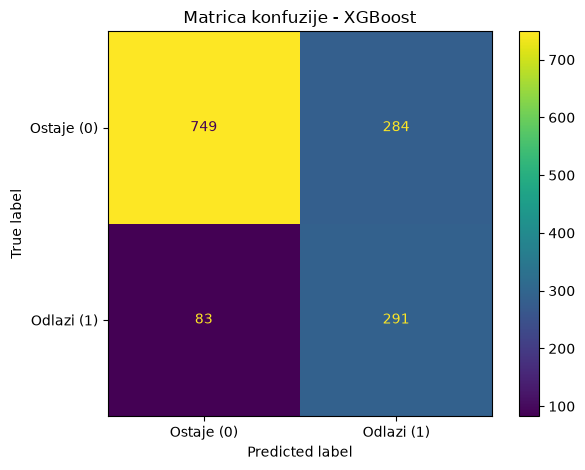

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_xgb = confusion_matrix(y_test, y_pred_xgb)

print("Matrica konfuzije:")
print(cm_xgb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb,
    display_labels=["Ostaje (0)", "Odlazi (1)"]
)

disp.plot()
plt.title("Matrica konfuzije - XGBoost")
plt.tight_layout()

plt.savefig(
    "../images/07_xgb_confusion_matrix.png",
    dpi=100,
    bbox_inches="tight"
)

plt.show()

### Tumačenje matrice konfuzije

XGBoost je pravilno prepoznao 291 korisnika koji su zaista otišli (TP),
dok mu je 83 takvih korisnika (FN) promaklo. Sa druge strane, 284
korisnika (FP) je označio kao rizične iako su ostali, a 749 korisnika
(TN) je tačno prepoznao kao one koji ostaju.

Kod problema churn-a, broj False Negative slučajeva je posebno bitan, jer
su to korisnici koji zaista odlaze, a model ih nije prepoznao na vreme.
XGBoost ovde ima Recall od 77.81%, što znači da je uhvatio veliki deo
korisnika koji su stvarno napustili kompaniju.

Model doduše pravi i određeni broj lažno pozitivnih predikcija, ali to je
u poslovnom smislu prihvatljivo, bolje je označiti korisnika kao rizičnog
pa da se ispostavi da je ostao, nego propustiti nekoga ko zaista odlazi.

## 5. Poređenje modela

Sad kad smo istrenirali i ocenili sva tri modela, upoređujemo ih jedan
naspram drugog po istim metrikama.

Cilj nije da odaberemo model samo po Accuracy-ju, već da uzmemo u obzir
sve metrike zajedno. Kod nas je Recall posebno bitan, jer želimo da model
prepozna što veći broj korisnika koji stvarno odlaze.

In [ ]:
# Kreiramo tabelu sa rezultatima sva tri modela.

rezultati_modela = pd.DataFrame({
    "Model": [
        "Logistička regresija",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_logreg,
        accuracy_rf,
        accuracy_xgb
    ],
    "Precision": [
        precision_logreg,
        precision_rf,
        precision_xgb
    ],
    "Recall": [
        recall_logreg,
        recall_rf,
        recall_xgb
    ],
    "F1-score": [
        f1_logreg,
        f1_rf,
        f1_xgb
    ],
    "ROC-AUC": [
        roc_auc_logreg,
        roc_auc_rf,
        roc_auc_xgb
    ]
})

# Zaokružujemo rezultate na 4 decimale.
rezultati_modela = rezultati_modela.round(4)

print("POREĐENJE MODELA")
print("=" * 80)

display(rezultati_modela)

POREĐENJE MODELA


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistička regresija,0.7242,0.4884,0.7888,0.6033,0.8342
1,Random Forest,0.7719,0.5598,0.6631,0.6071,0.8215
2,XGBoost,0.7392,0.5061,0.7781,0.6133,0.8301


### 5.2 Grafičko poređenje modela

Pored tabele, iste rezultate prikazujemo i na grafikonu, tako se razlike
između modela lakše uočavaju na prvi pogled.

Upoređujemo Accuracy, Precision, Recall, F1-score i ROC-AUC.

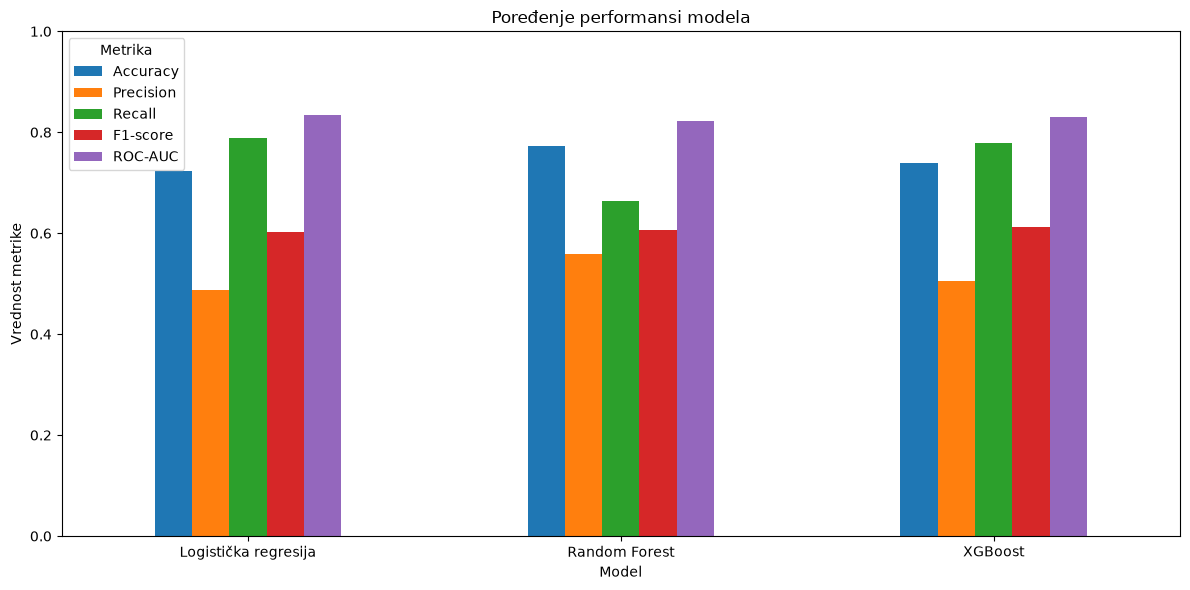

In [ ]:
import matplotlib.pyplot as plt

metrike = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]

rezultati_modela.set_index("Model")[metrike].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Poređenje performansi modela")
plt.xlabel("Model")
plt.ylabel("Vrednost metrike")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metrika")
plt.tight_layout()

plt.savefig(
    "../images/07_model_comparison.png",
    dpi=100,
    bbox_inches="tight"
)

plt.show()

### 5.3 Izbor najboljeg modela

Pri izboru konačnog modela gledamo sve metrike, ali nama su najvažniji
Recall i F1-score.

Recall nam pokazuje koliko dobro model prepoznaje korisnike koji zaista
odlaze, a F1-score je neka vrsta ravnoteže između Recall-a i Precision-a.

Kad pogledamo rezultate, XGBoost ima najbolji F1-score (0.6133),
logistička regresija najbolji Recall (0.7888) i ROC-AUC (0.8342), dok
Random Forest ima najbolju Accuracy (0.7719) i Precision (0.5598), ali
zato i najniži Recall (0.6631).

Ne postoji, dakle, jedan model koji je bolji od ostalih po svim
kriterijumima, izbor zavisi od toga šta nam je u konkretnom slučaju
najbitnije.

Kako je nama ovde ključno da uhvatimo što više korisnika koji zaista
odlaze, logistička regresija nam deluje kao najbolji izbor, s obzirom na
najviši Recall i ROC-AUC. XGBoost joj je ipak ozbiljna konkurencija,
zahvaljujući najboljem F1-score-u.

## 6. Analiza važnosti atributa (Feature Importance)

Pored samih metrika, korisno je videti i koji atributi najviše doprinose
predikciji. To nam pomaže na dva načina.

Prvo, lakše objašnjavamo poslovnim korisnicima zašto model misli da će
neki korisnik otići. Drugo, možemo proveriti da li su nove promenljive
koje smo napravili u svesci `05` (`ActiveServices`, `TenureGroup`) zaista
korisne modelu, ili su bile suvišne.

Kod Logističke regresije gledamo koeficijente, predznak nam govori u kom
pravcu utiču, a veličina koliko jako. Kod Random Forest-a i XGBoost-a
koristimo ugrađenu meru `feature_importances_`.

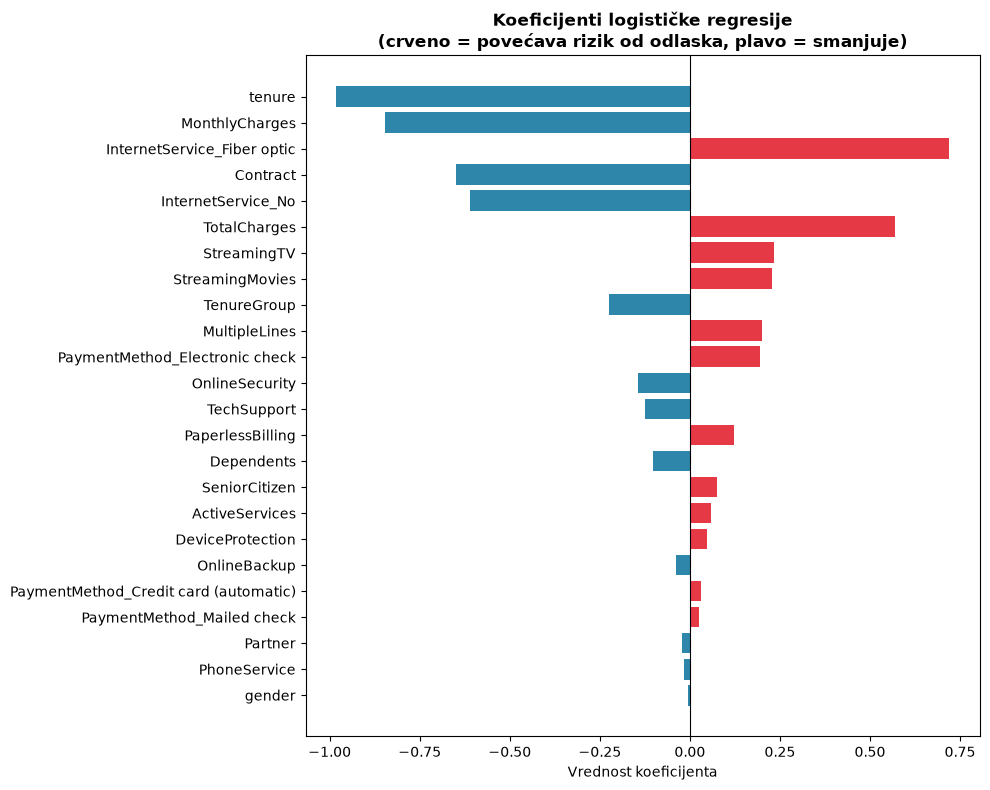

Top 5 atributa koji NAJVIŠE POVEĆAVAJU rizik od odlaska:
InternetService_Fiber optic    0.720279
TotalCharges                   0.568154
StreamingTV                    0.233508
StreamingMovies                0.227818
MultipleLines                  0.199327
dtype: float64

Top 5 atributa koji NAJVIŠE SMANJUJU rizik od odlaska:
tenure               -0.981802
MonthlyCharges       -0.846516
Contract             -0.649496
InternetService_No   -0.611559
TenureGroup          -0.224809
dtype: float64


In [ ]:
import numpy as np

koef_logreg = pd.Series(model_logreg.coef_[0], index=X_train.columns)
koef_logreg_sorted = koef_logreg.reindex(koef_logreg.abs().sort_values(ascending=False).index)

plt.figure(figsize=(10, 8))
colors_bar = ["#E63946" if v > 0 else "#2E86AB" for v in koef_logreg_sorted]
plt.barh(koef_logreg_sorted.index[::-1], koef_logreg_sorted.values[::-1], color=colors_bar[::-1])
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Koeficijenti logističke regresije\n(crveno = povećava rizik od odlaska, plavo = smanjuje)", fontweight="bold")
plt.xlabel("Vrednost koeficijenta")
plt.tight_layout()
plt.savefig("../images/07_logreg_coefficients.png", dpi=100, bbox_inches="tight")
plt.show()

print("Top 5 atributa koji NAJVIŠE POVEĆAVAJU rizik od odlaska:")
print(koef_logreg.sort_values(ascending=False).head(5))
print("\nTop 5 atributa koji NAJVIŠE SMANJUJU rizik od odlaska:")
print(koef_logreg.sort_values().head(5))

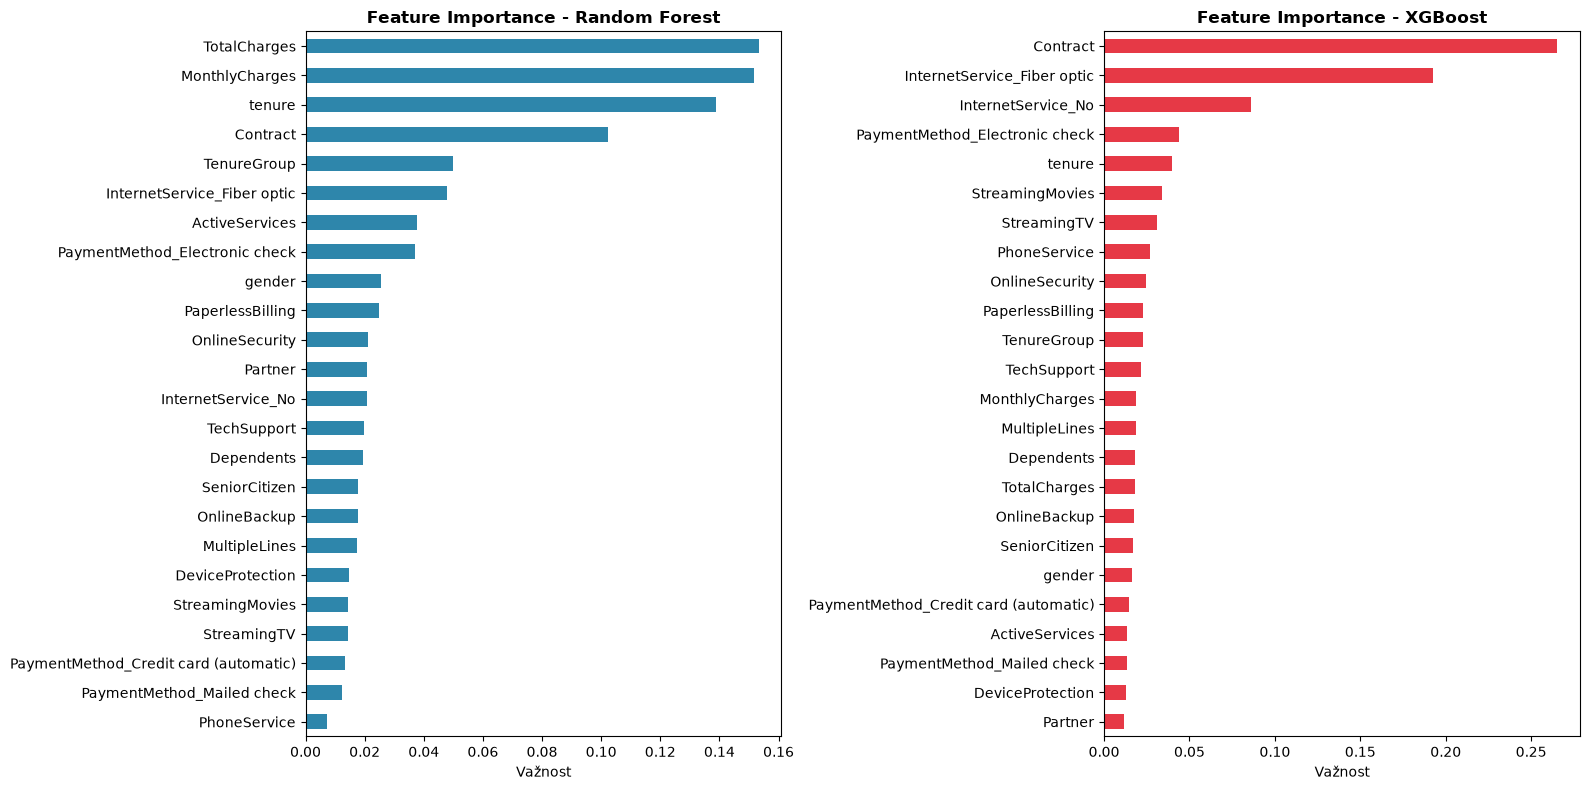

Top 5 najvažnijih atributa - Random Forest:
TotalCharges      0.153321
MonthlyCharges    0.151618
tenure            0.138996
Contract          0.102336
TenureGroup       0.049920
dtype: float64

Top 5 najvažnijih atributa - XGBoost:
Contract                          0.265308
InternetService_Fiber optic       0.192599
InternetService_No                0.085996
PaymentMethod_Electronic check    0.043767
tenure                            0.039555
dtype: float32


In [ ]:
importance_rf = pd.Series(model_rf.feature_importances_, index=X_train.columns)
importance_xgb = pd.Series(model_xgb.feature_importances_, index=X_train.columns)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

importance_rf.sort_values().plot(kind="barh", ax=axes[0], color="#2E86AB")
axes[0].set_title("Feature Importance - Random Forest", fontweight="bold")
axes[0].set_xlabel("Važnost")

importance_xgb.sort_values().plot(kind="barh", ax=axes[1], color="#E63946")
axes[1].set_title("Feature Importance - XGBoost", fontweight="bold")
axes[1].set_xlabel("Važnost")

plt.tight_layout()
plt.savefig("../images/07_feature_importance_rf_xgb.png", dpi=100, bbox_inches="tight")
plt.show()

print("Top 5 najvažnijih atributa - Random Forest:")
print(importance_rf.sort_values(ascending=False).head(5))
print("\nTop 5 najvažnijih atributa - XGBoost:")
print(importance_xgb.sort_values(ascending=False).head(5))

### Tumačenje: važnost atributa

Kod sva tri modela se `Contract`, `tenure` i `MonthlyCharges` izdvajaju
kao najvažniji, što se poklapa sa onim što smo videli u statističkoj
analizi u svesci `06`.

Što se tiče novih promenljivih koje smo napravili: `ActiveServices` kod
Random Forest-a i XGBoost-a ima umeren do visok uticaj, što znači da broj
aktivnih dodatnih usluga zaista nosi neku prediktivnu vrednost, taj korak
se isplatio. `TenureGroup`, s druge strane, kod modela baziranih na
stablima ima manji značaj od sirovog `tenure`, i to je donekle
očekivano, jer ti modeli sami umeju da pronađu gde da postave prag
podele na numeričkoj promenljivoj, pa im grupisana verzija ne donosi
mnogo novog. Kod Logističke regresije je drugačije, tu je model linearan
i grupisana promenljiva mu pomaže da uhvati nelinearne efekte koje inače
ne bi video.

### 6.1 Permutaciona važnost atributa

`feature_importances_` kod Random Forest-a i XGBoost-a računa se na
drugačiji način kod svakog modela (impurity decrease kod RF, gain kod
XGBoost), pa nije striktno uporediva između modela, a kod koreliranih
numeričkih kolona (`TotalCharges`, `MonthlyCharges`, `tenure`) impurity
importance kod RF-a ume da bude nepouzdana, jer se "zasluga" deli između
koreliranih atributa na nasumičan način.

Permutaciona važnost (`sklearn.inspection.permutation_importance`) meri
nešto direktnije: za koliko opadne performansa modela na **test skupu**
kada se vrednosti jedne kolone nasumično promešaju, čime se ta kolona
efektivno "pokvari", a sve ostalo ostaje isto. Pošto se meri u istoj
jedinici (pad odabrane metrike) za oba modela, ovo nam daje pravednije
poređenje i proveru da li je razilaženje u top 5 atributima između RF-a
i XGBoost-a stvarno ili je artefakt načina računanja ugrađene važnosti.

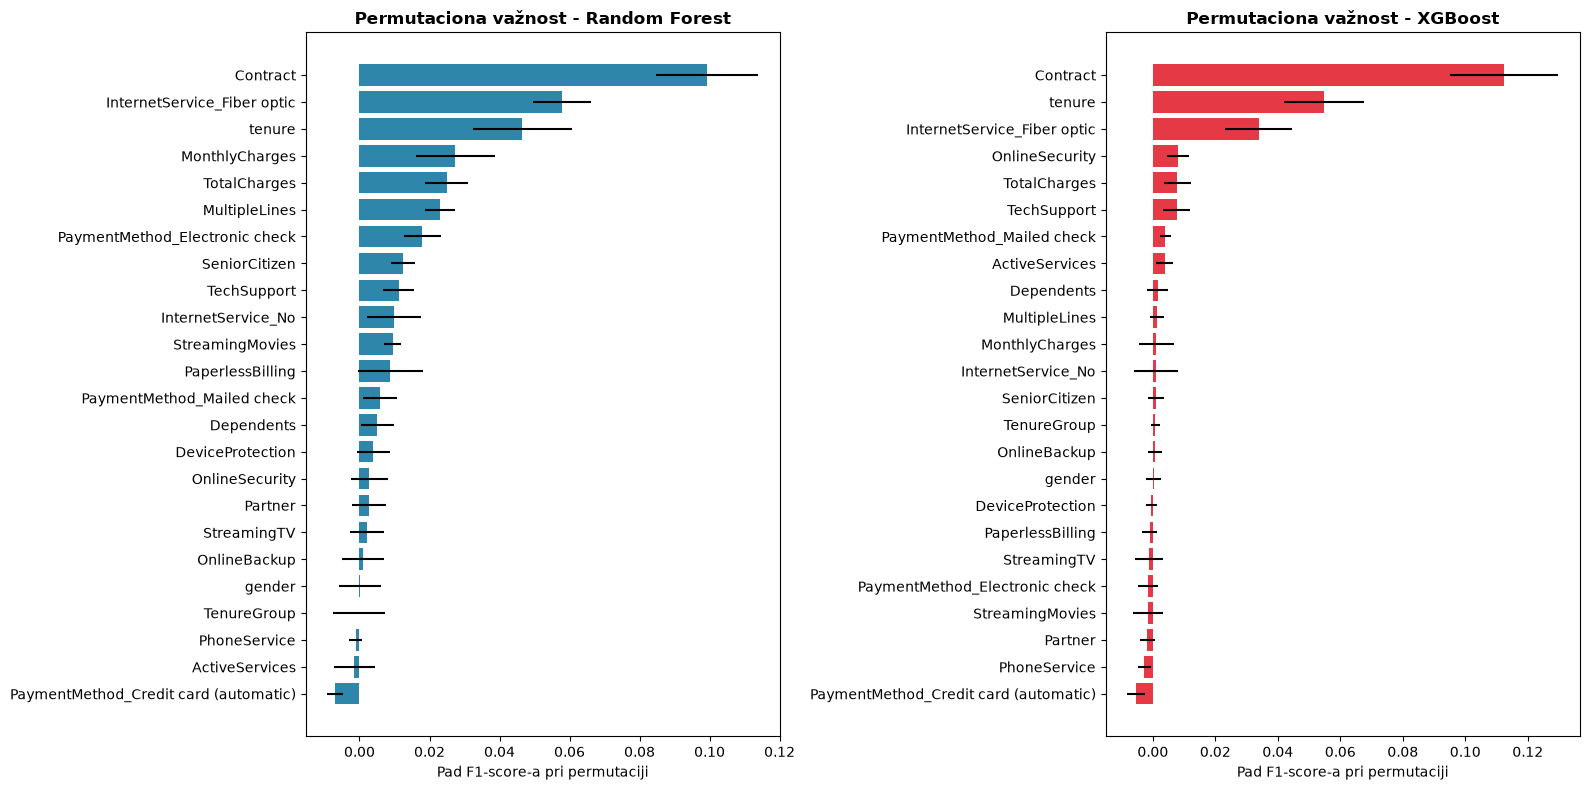

Top 5 - permutaciona važnost (Random Forest):
Contract                       0.099350
InternetService_Fiber optic    0.057967
tenure                         0.046529
MonthlyCharges                 0.027402
TotalCharges                   0.024898
dtype: float64

Top 5 - permutaciona važnost (XGBoost):
Contract                       0.112468
tenure                         0.054779
InternetService_Fiber optic    0.033855
OnlineSecurity                 0.008154
TotalCharges                   0.007819
dtype: float64

Za poređenje, ugrađena (impurity/gain) važnost - top 5:
Random Forest:
TotalCharges      0.153321
MonthlyCharges    0.151618
tenure            0.138996
Contract          0.102336
TenureGroup       0.049920
dtype: float64

XGBoost:
Contract                          0.265308
InternetService_Fiber optic       0.192599
InternetService_No                0.085996
PaymentMethod_Electronic check    0.043767
tenure                            0.039555
dtype: float32


In [ ]:
from sklearn.inspection import permutation_importance

# Permutacionu važnost računamo na TEST skupu, jer nas zanima koliko
# svaki atribut zaista doprinosi generalizaciji modela na nove podatke,
# a ne koliko je "iskorišćen" prilikom građenja stabala na trening skupu.
perm_rf = permutation_importance(
    model_rf, X_test, y_test,
    scoring="f1", n_repeats=10, random_state=42, n_jobs=-1
)
perm_xgb = permutation_importance(
    model_xgb, X_test, y_test,
    scoring="f1", n_repeats=10, random_state=42, n_jobs=-1
)

perm_importance_rf = pd.Series(perm_rf.importances_mean, index=X_test.columns)
perm_importance_xgb = pd.Series(perm_xgb.importances_mean, index=X_test.columns)
perm_std_rf = pd.Series(perm_rf.importances_std, index=X_test.columns)
perm_std_xgb = pd.Series(perm_xgb.importances_std, index=X_test.columns)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

redosled_rf = perm_importance_rf.sort_values().index
axes[0].barh(redosled_rf, perm_importance_rf[redosled_rf],
             xerr=perm_std_rf[redosled_rf], color="#2E86AB")
axes[0].set_title("Permutaciona važnost - Random Forest", fontweight="bold")
axes[0].set_xlabel("Pad F1-score-a pri permutaciji")

redosled_xgb = perm_importance_xgb.sort_values().index
axes[1].barh(redosled_xgb, perm_importance_xgb[redosled_xgb],
             xerr=perm_std_xgb[redosled_xgb], color="#E63946")
axes[1].set_title("Permutaciona važnost - XGBoost", fontweight="bold")
axes[1].set_xlabel("Pad F1-score-a pri permutaciji")

plt.tight_layout()
plt.savefig("../images/07_permutation_importance_rf_xgb.png", dpi=100, bbox_inches="tight")
plt.show()

print("Top 5 - permutaciona važnost (Random Forest):")
print(perm_importance_rf.sort_values(ascending=False).head(5))
print("\nTop 5 - permutaciona važnost (XGBoost):")
print(perm_importance_xgb.sort_values(ascending=False).head(5))

print("\nZa poređenje, ugrađena (impurity/gain) važnost - top 5:")
print("Random Forest:")
print(importance_rf.sort_values(ascending=False).head(5))
print("\nXGBoost:")
print(importance_xgb.sort_values(ascending=False).head(5))

Poređenjem permutacione i ugrađene važnosti proveravamo da li razilaženje
u top 5 atributima između Random Forest-a i XGBoost-a ostaje i kada se
meri na isti način. Poređenje potvrđuje pretpostavku: permutacijom, `Contract` postaje ubedljivo
najvažniji atribut i za Random Forest (0,099 pada F1-score-a, najveće od svih
promenljivih), iako je u impurity-based rangiranju bio tek na 4. mestu
(0,102, iza tri korelirane numeričke naplatne kolone). Ovo pokazuje da RF
`Contract` zaista intenzivno koristi pri predikciji, samo što impurity-based
mera to nije verno prikazala zbog korelacije sa `TotalCharges`,
`MonthlyCharges` i `tenure`. Kod XGBoost-a se rang slaže i kod jedne i kod
druge mere — `Contract` je ubedljivo prvi u oba slučaja — pa je razilaženje
između modela na kraju bilo više artefakt načina računanja importance-a kod
Random Forest-a, nego stvarna razlika u tome šta modeli koriste.

## 7. Cross-validacija

Do sada smo modele evaluirali samo na jednoj podeli trening/test skupa,
a rezultati koje smo dobili mogu delom biti stvar slučaja, zavisno od
toga koji su korisnici baš završili u test skupu.

Da bismo dobili pouzdaniju procenu, primenjujemo stratifikovanu 5-struku
unakrsnu validaciju (Stratified 5-Fold Cross-Validation) na trening
skupu. Ideja je da se trening skup podeli na 5 delova, model trenira na
4 dela i testira na petom, i to se ponovi 5 puta tako da svaki deo jednom
bude test skup. Konačna ocena je onda prosek svih 5 iteracija.

Bitno je napomenuti da ovo radimo isključivo na trening skupu (`X_train`,
`y_train`), test skup i dalje ostaje netaknut i čuva se za finalnu
evaluaciju.

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ["f1", "recall", "roc_auc"]

pipe_logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
])

cv_results = {}

for naziv, model_cv in [
    ("Logistička regresija", pipe_logreg),
    ("Random Forest", RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1)),
    ("XGBoost", XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8,
                               colsample_bytree=0.8, scale_pos_weight=scale_pos_weight,
                               random_state=42, eval_metric="logloss"))
]:
    rezultat = cross_validate(model_cv, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    cv_results[naziv] = rezultat
    print(f"{naziv}:")
    for metrika in scoring:
        vrednosti = rezultat[f"test_{metrika}"]
        print(f"  {metrika:10s}: {vrednosti.mean():.4f} ± {vrednosti.std():.4f}")
    print()

Logistička regresija:
  f1        : 0.6326 ± 0.0080
  recall    : 0.8033 ± 0.0166
  roc_auc   : 0.8458 ± 0.0055

Random Forest:
  f1        : 0.6041 ± 0.0174
  recall    : 0.6395 ± 0.0266
  roc_auc   : 0.8313 ± 0.0084

XGBoost:
  f1        : 0.6345 ± 0.0074
  recall    : 0.7692 ± 0.0110
  roc_auc   : 0.8460 ± 0.0068



### Tumačenje cross-validacije

Poredeći rezultate cross-validacije sa onim što smo dobili na jednom test
skupu (sekcija 5), vidimo da li su performanse stabilne ili je model
imao "sreće" sa podelom podataka. Ako je standardna devijacija (± vrednost)
kroz 5 foldova mala, znači da model daje slične rezultate bez obzira koji
su korisnici u pitanju, a to nam daje više poverenja u dobijene metrike.

S druge strane, da su prosečne vrednosti iz cross-validacije bile
znatno drugačije od rezultata na test skupu, to bi bio signal da je
test skup možda nereprezentativan i da rezultate treba uzeti sa rezervom.

## 8. Podešavanje hiperparametara

Do sada smo modele puštali sa parametrima koje smo sami odabrali, razumnim
ali proizvoljnim. Sad pokušavamo da sistematski nađemo bolju kombinaciju,
pomoću pretrage po mreži ili slučajne pretrage, za dva modela koja su se
do sada najbolje pokazala: logističku regresiju (najbolji Recall i AUC) i
XGBoost (najbolji F1-score).

Pretragu radimo isključivo na trening skupu, uz istu stratifikovanu
5-struku cross-validaciju kao malopre, sa `f1` kao metrikom koju
optimizujemo (jer balansira Precision i Recall).

In [ ]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import warnings
warnings.filterwarnings("ignore")  # sklearn ispisuje mnogo deprecation upozorenja za "penalty" parametar

# --- Grid Search za logističku regresiju ---
param_grid_logreg = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__penalty": ["l1", "l2"],
    "model__solver": ["liblinear"]
}

grid_logreg = GridSearchCV(
    pipe_logreg,
    param_grid_logreg,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)
grid_logreg.fit(X_train, y_train)

print("Najbolji parametri (Logistička regresija):", grid_logreg.best_params_)
print(f"Najbolji F1-score (cross-validacija): {grid_logreg.best_score_:.4f}")

Najbolji parametri (Logistička regresija): {'model__C': 1, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
Najbolji F1-score (cross-validacija): 0.6328


In [ ]:
# --- Randomized Search za XGBoost ---
param_dist_xgb = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0]
}

random_xgb = RandomizedSearchCV(
    XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42, eval_metric="logloss"),
    param_distributions=param_dist_xgb,
    n_iter=20,
    cv=cv,
    scoring="f1",
    random_state=42,
    n_jobs=-1
)
random_xgb.fit(X_train, y_train)

print("Najbolji parametri (XGBoost):", random_xgb.best_params_)
print(f"Najbolji F1-score (cross-validacija): {random_xgb.best_score_:.4f}")

Najbolji parametri (XGBoost): {'subsample': 0.7, 'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
Najbolji F1-score (cross-validacija): 0.6391


In [ ]:
# --- Evaluacija podešenih modela na test skupu ---
best_logreg = grid_logreg.best_estimator_
best_xgb = random_xgb.best_estimator_

y_pred_logreg_tuned = best_logreg.predict(X_test)
y_prob_logreg_tuned = best_logreg.predict_proba(X_test)[:, 1]

y_pred_xgb_tuned = best_xgb.predict(X_test)
y_prob_xgb_tuned = best_xgb.predict_proba(X_test)[:, 1]

poredjenje_tuning = pd.DataFrame({
    "Model": [
        "Logistička regresija (pre)",
        "Logistička regresija (posle tuning-a)",
        "XGBoost (pre)",
        "XGBoost (posle tuning-a)"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_logreg),
        accuracy_score(y_test, y_pred_logreg_tuned),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_xgb_tuned)
    ],
    "Precision": [
        precision_score(y_test, y_pred_logreg),
        precision_score(y_test, y_pred_logreg_tuned),
        precision_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_xgb_tuned)
    ],
    "Recall": [
        recall_score(y_test, y_pred_logreg),
        recall_score(y_test, y_pred_logreg_tuned),
        recall_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_xgb_tuned)
    ],
    "F1-score": [
        f1_score(y_test, y_pred_logreg),
        f1_score(y_test, y_pred_logreg_tuned),
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_xgb_tuned)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_logreg),
        roc_auc_score(y_test, y_prob_logreg_tuned),
        roc_auc_score(y_test, y_prob_xgb),
        roc_auc_score(y_test, y_prob_xgb_tuned)
    ]
}).round(4)

display(poredjenje_tuning)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistička regresija (pre),0.7242,0.4884,0.7888,0.6033,0.8342
1,Logistička regresija (posle tuning-a),0.7249,0.4892,0.7861,0.6031,0.8347
2,XGBoost (pre),0.7392,0.5061,0.7781,0.6133,0.8301
3,XGBoost (posle tuning-a),0.7385,0.5050,0.8048,0.6206,0.8417


### Tumačenje podešavanja hiperparametara

Ovim poređenjem vidimo da li je sistematska pretraga parametara donela
neko poboljšanje u odnosu na vrednosti koje smo ručno odabrali na
početku. Čak i kad poboljšanje nije veliko, ovaj korak ima smisla, jer
pokazuje da smo do finalnih parametara došli sistematski, a ne
proizvoljno, umesto da se oslonimo samo na podrazumevane vrednosti.

Ako se pokaže da podešeni model nije bolji od početnog, ni to nije
loš nalaz, znači da je model već blizu svog "plafona" sa ovim skupom
atributa, i da bi za dalje poboljšanje trebalo raditi pre svega na
novim feature-ima, ne na parametrima.

### Podešavanje praga odlučivanja

Do sada smo klasu dodeljivali po podrazumevanom pravilu: ako je
predviđena verovatnoća odlaska ≥ 0,5, korisnik se svrstava u klasu 1.
Taj prag nije nikakav prirodni zakon, samo default vrednost, i ne mora
biti optimalan za naš problem.

Pošto nam je Recall prioritet (skuplje je propustiti korisnika koji
zaista odlazi nego lažno uzbuniti se oko lojalnog), ima smisla proveriti
šta se dešava sa Precision, Recall i F1-score kada pomeramo prag naniže
ili naviše, umesto da se držimo defaulta bez razmišljanja.

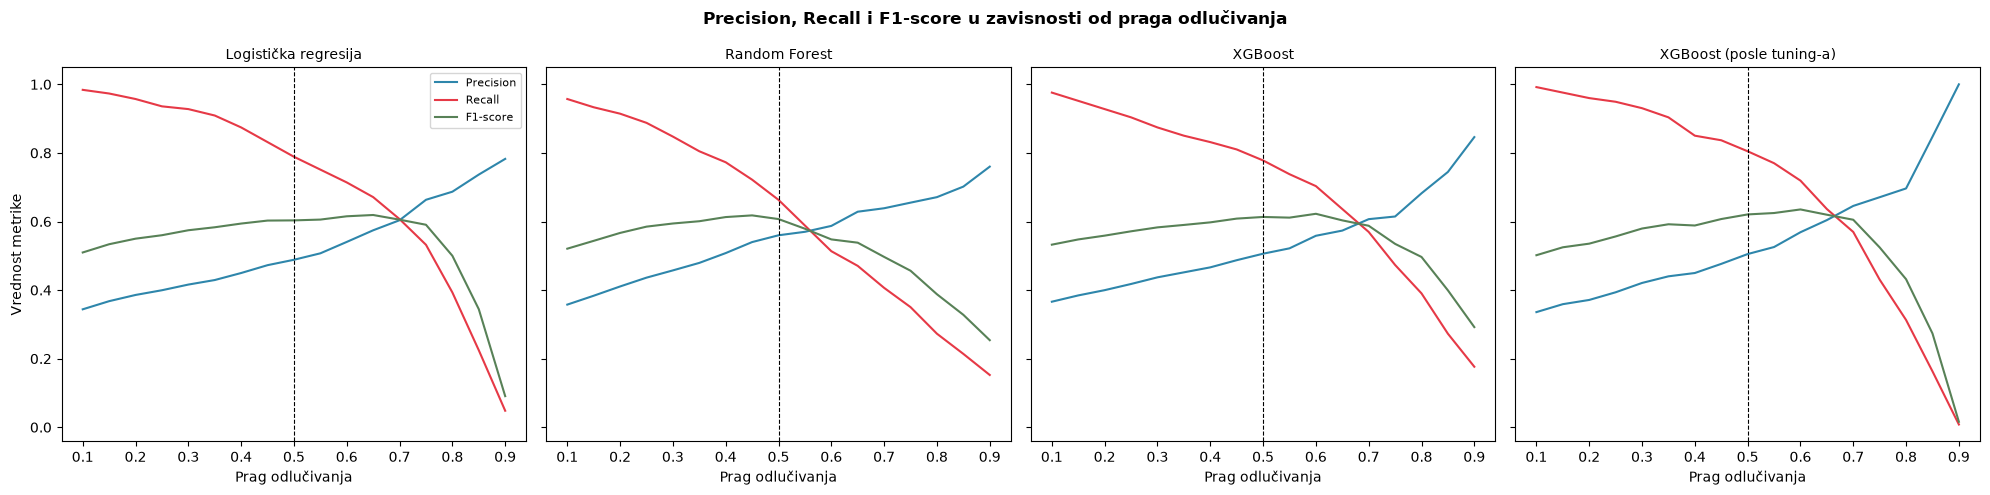

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

pragovi = np.arange(0.1, 0.95, 0.05)

verovatnoce_modela = {
    "Logistička regresija": y_prob_logreg,
    "Random Forest": y_prob_rf,
    "XGBoost": y_prob_xgb,
    "XGBoost (posle tuning-a)": y_prob_xgb_tuned,
}

rezultati_pragova = []
for naziv, y_prob in verovatnoce_modela.items():
    for prag in pragovi:
        y_pred_prag = (y_prob >= prag).astype(int)
        rezultati_pragova.append({
            "Model": naziv,
            "Prag": round(prag, 2),
            "Precision": precision_score(y_test, y_pred_prag, zero_division=0),
            "Recall": recall_score(y_test, y_pred_prag),
            "F1-score": f1_score(y_test, y_pred_prag)
        })

df_pragovi = pd.DataFrame(rezultati_pragova)

fig, axes = plt.subplots(1, len(verovatnoce_modela), figsize=(20, 5), sharey=True)
for ax, naziv in zip(axes, verovatnoce_modela.keys()):
    podskup = df_pragovi[df_pragovi["Model"] == naziv]
    ax.plot(podskup["Prag"], podskup["Precision"], label="Precision", color="#2E86AB")
    ax.plot(podskup["Prag"], podskup["Recall"], label="Recall", color="#E63946")
    ax.plot(podskup["Prag"], podskup["F1-score"], label="F1-score", color="#588157")
    ax.axvline(0.5, color="black", linestyle="--", linewidth=0.8)
    ax.set_title(naziv, fontsize=10)
    ax.set_xlabel("Prag odlučivanja")

axes[0].set_ylabel("Vrednost metrike")
axes[0].legend(fontsize=8)
plt.suptitle("Precision, Recall i F1-score u zavisnosti od praga odlučivanja", fontweight="bold")
plt.tight_layout()
plt.savefig("../images/07_pragovi_odlucivanja.png", dpi=100, bbox_inches="tight")
plt.show()

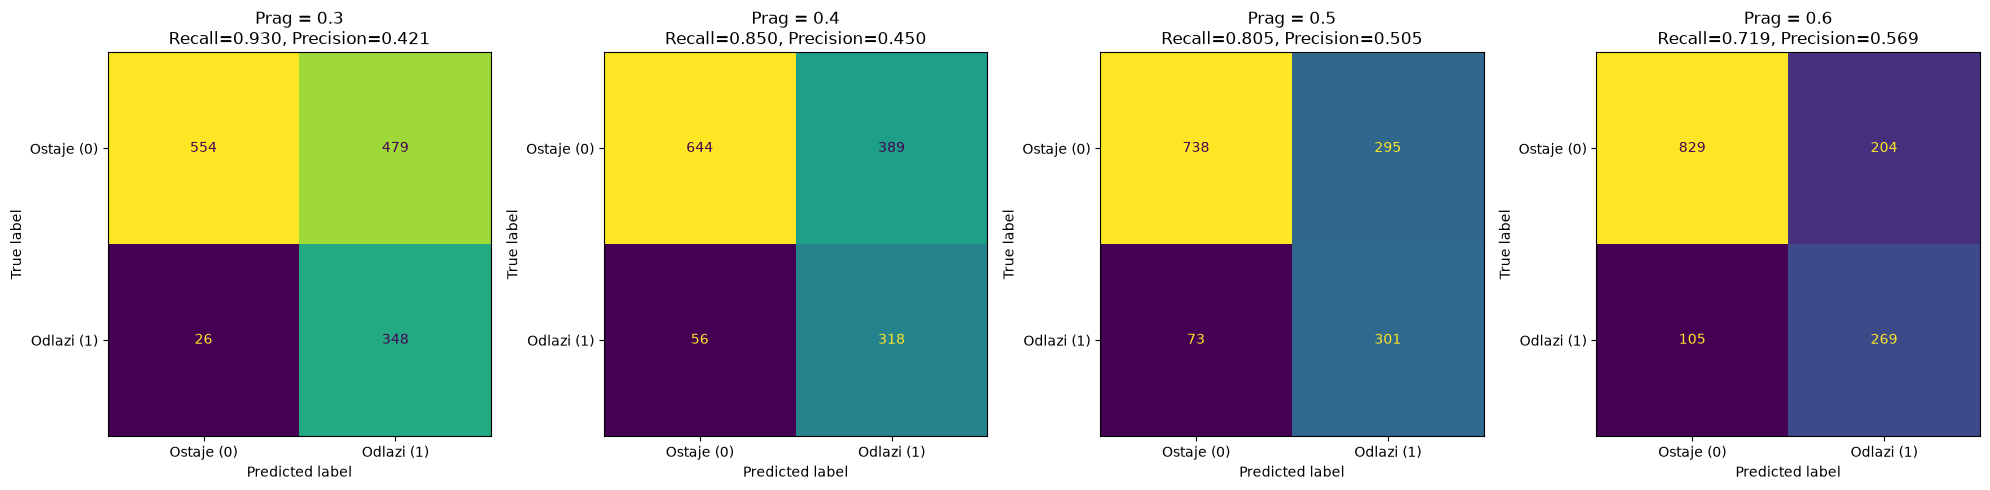

In [ ]:
izabrani_pragovi = [0.3, 0.4, 0.5, 0.6]

fig, axes = plt.subplots(1, len(izabrani_pragovi), figsize=(20, 5))
for ax, prag in zip(axes, izabrani_pragovi):
    y_pred_prag = (y_prob_xgb_tuned >= prag).astype(int)
    cm_prag = confusion_matrix(y_test, y_pred_prag)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_prag, display_labels=["Ostaje (0)", "Odlazi (1)"])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(
        f"Prag = {prag}\n"
        f"Recall={recall_score(y_test, y_pred_prag):.3f}, "
        f"Precision={precision_score(y_test, y_pred_prag, zero_division=0):.3f}"
    )

plt.tight_layout()
plt.savefig("../images/07_matrice_po_pragovima.png", dpi=100, bbox_inches="tight")
plt.show()

Kao što se vidi na grafiku, spuštanje praga ispod 0,5 dosledno povećava
Recall, ali po cenu Precision-a i F1-score-a. Za XGBoost (posle tuning-a):
na pragu 0,3 Recall raste na 93,0% (sa 80,5% na pragu 0,5), ali Precision
pada na 42,1% (sa 50,5%), a F1-score opada sa 0,621 na 0,580. Na pragu 0,4
je odnos blaži (Recall 85,0%, Precision 45,0%, F1 0,589), ali i dalje niži
F1 nego na 0,5. F1-score je zapravo maksimalan negde oko praga 0,6, a ne
na 0,3-0,4.

Ipak, pošto nam je kod churn problema Recall poslovni prioritet, a ne
F1-score sam po sebi, spuštanje praga na 0,3 ili 0,4 i dalje može biti
opravdano: broj propuštenih stvarnih odlazaka (FN) pada sa 73 (na pragu
0,5) na svega 26 (na pragu 0,3), po cenu znatno više lažnih alarma (FP
raste sa 295 na 479). Prag iznad 0,5 ide u suprotnom smeru (viši
Precision, niži Recall) i nije u skladu sa našim prioritetom.

## 9. ROC krive: grafičko poređenje modela

ROC (Receiver Operating Characteristic) kriva pokazuje odnos između True
Positive Rate-a (Recall) i False Positive Rate-a, za sve moguće pragove
odlučivanja modela. Što je kriva bliža gornjem levom uglu, to model bolje
razdvaja dve klase. AUC, površina ispod krive, sve to svodi na jedan broj,
što je bliže 1, model je bolji.

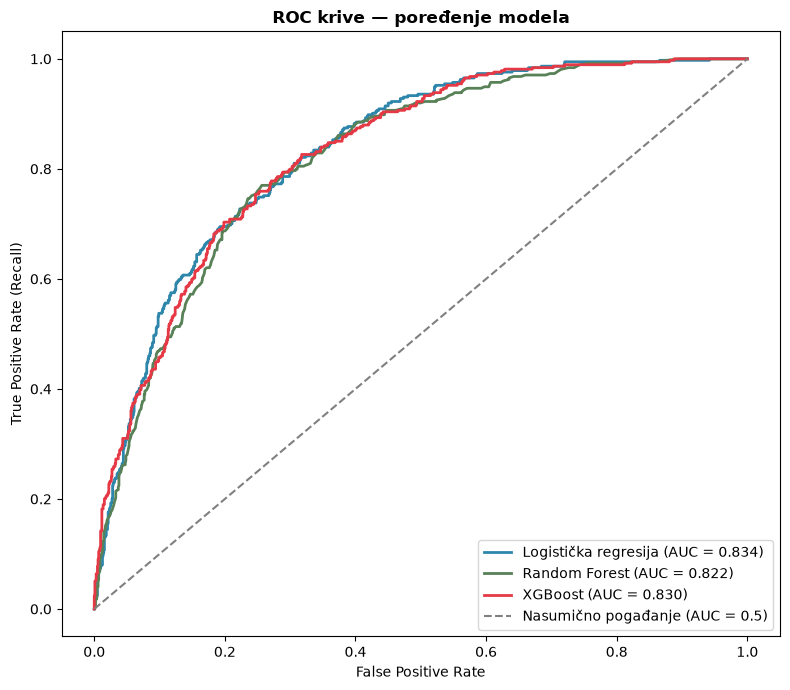

In [ ]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 7))

for naziv, y_prob, boja in [
    ("Logistička regresija", y_prob_logreg, "#2E86AB"),
    ("Random Forest", y_prob_rf, "#588157"),
    ("XGBoost", y_prob_xgb, "#E63946"),
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{naziv} (AUC = {auc_val:.3f})", color=boja, linewidth=2)

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Nasumično pogađanje (AUC = 0.5)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC krive — poređenje modela", fontweight="bold")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../images/07_roc_curves.png", dpi=100, bbox_inches="tight")
plt.show()

## 10. Zaključak

U ovoj svesci smo izgradili i ocenili tri modela za predviđanje odlaska
korisnika: logističku regresiju, Random Forest i XGBoost.

Sva tri smo trenirali na trening skupu i proverili na nezavisnom test
skupu, kroz Accuracy, Precision, Recall, F1-score i ROC-AUC.

Kad pogledamo rezultate, Random Forest ima najveću Accuracy, logistička
regresija najveći Recall i ROC-AUC, a XGBoost najbolji F1-score.

Pošto nam je kod churn-a najbitnije da na vreme prepoznamo korisnike koji
odlaze, Recall je za nas ključna metrika, i po tom kriterijumu logistička
regresija se izdvaja kao najpogodniji izbor, dok je XGBoost i dalje
ozbiljna alternativa zahvaljujući najboljem F1-score-u.

Ovi modeli su dobra osnova za dalju optimizaciju i eventualno
finije podešavanje parametara.

Kroz dodatne provere u sekcijama 6 do 9 smo, između ostalog, potvrdili
da novi feature `ActiveServices` zaista nosi prediktivnu vrednost, da
rezultati nisu slučajni (standardna devijacija kroz 5 foldova je mala),
da je podešavanje hiperparametara sprovedeno sistematski kroz Grid i
Randomized Search za dva najbolja modela, i da ROC krive pokazuju da sva
tri modela jasno nadmašuju nasumično pogađanje (AUC > 0.5).